### Delta Hedging Option Position
Using Black-Scholes-Merton we can find the value of an option over time and we can evaluate our position 

We want to hedge a given position with options to be delta neutral

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [14]:
def bsm_option(S, K, t, sigma, rf, type='put'):
    """
    S: Underlying asset value
    K: Strike price
    t: time-span of option (annualized)
    sigma: volatility
    rf: risk-free rate (annualized)
    type: type of written option
    """
    d1 = (np.log(S / K) + (rf + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)
    d2 = d1 - sigma * np.sqrt(t)

    if type.lower() == 'put':
        cdf_d1 = scipy.stats.norm.cdf(-d1)
        cdf_d2 = scipy.stats.norm.cdf(-d2)
        value = K * np.exp(-rf * t) * cdf_d2 - S * cdf_d1
        delta = -cdf_d1
        return {'type': type,
                'value': value,
                'delta': delta}

    if type.lower() == 'call':
        cdf_d1 = scipy.stats.norm.cdf(d1)
        cdf_d2 = scipy.stats.norm.cdf(d2)
        value = S * cdf_d1 - K * np.exp(-rf * t) * cdf_d2
        delta = cdf_d1
        return {'type': type,
                'value': value,
                'delta': delta}

In [15]:
### Consider the following scenario
t = 90/365
S = 60
K = 60
rf = 0.08
sigma = 0.3
typeOption = 'call'

bsm_option(S, K, t, sigma, rf, type=typeOption)

{'type': 'call',
 'value': np.float64(4.1445229602782945),
 'delta': np.float64(0.5819565966075844)}

Suppose we write z = -1000 call options

At stipulation we have: 
- Option value = 4.14452
- Option delta = 0.58196
- `Writing`: allows us to collect 1000 * 4.14452 = $4144.52
- `Hedging`: 
    - delta neutral requires to purchase x = 1000 * 0.58196 = 581.96 shares of stock
    - cost of purchase x * S = $34917.39
- `Borrowing`: in order to purchase the stock we need to borrow $4144.52 - $34917.39 = -$30772.87

In [16]:
def portfolio_position(S, K, t, sigma, rf, typeOption, daysPassed, x, y, z):
    daysRemaining = t - daysPassed
    valueStocks = x * S
    valueCash = y * np.exp(rf * daysPassed)
    valueOptions = bsm_option(S, K, daysRemaining, sigma, rf, typeOption)['value']
    return valueStocks + valueCash + z * valueOptions

In [29]:
# Analysis of portfolio after 1 day, 89 days remaining
daysPassed = 1/365

# Potential stock values
stockValues = np.linspace(50, 70, 20001)

x, y, z = 581.96, -30772.87, -1000
hedgingPosition = [portfolio_position(S, K, t, sigma, rf, typeOption, daysPassed, x, y, z) for S in stockValues]

x, y, z = 0, 4144.52, -1000
nakedPosition = [portfolio_position(S, K, t, sigma, rf, typeOption, daysPassed, x, y, z) for S in stockValues]

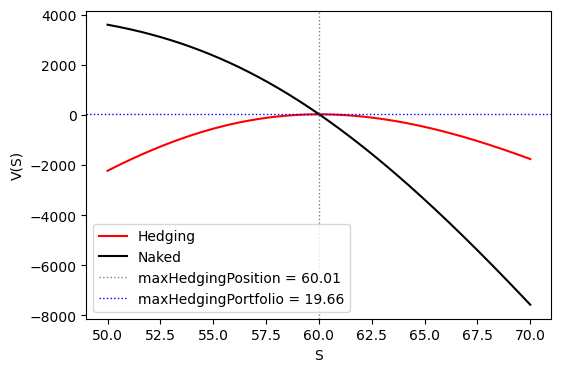

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(stockValues, hedgingPosition, color='red', label='Hedging')
ax.plot(stockValues, nakedPosition, color='black', label='Naked')

maxHedgingPosition = stockValues[np.argmax(hedgingPosition)]
maxHedgingPortfolio = np.max(hedgingPosition)
ax.axvline(maxHedgingPosition, lw=1, ls=':', color='grey', label=f'maxHedgingPosition = {round(maxHedgingPosition, 2)}')
ax.axhline(maxHedgingPortfolio, lw=1, ls=':', color='blue', label=f'maxHedgingPortfolio = {round(maxHedgingPortfolio, 2)}')
ax.set_xlabel('S')
ax.set_ylabel('V(S)')
ax.legend()
plt.show()